# Generating training data of HRTEM images for neural network 
This notebook generates training dataset for UNet, by applying variations to the origional image and mask, and output to the correct folder dir and format


Meng Li
20230607


In [1]:
"""
Load file
"""
# !pip install insituTEM
from insituTEM import insitu_IO as IO
from insituTEM import insitu_DP as DP
from insituTEM import insitu_alignment as AL
from insituTEM import insitu_Preprocess as PP


import easygui
import cv2
import tifffile

# # Change width of Jupyter Notebook
# from IPython.core.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

# path =  easygui.fileopenbox("Select the IFFT stack") # This easygui package works for windows, but not for mac
## for mac, option+right click the file, copy as pathname and paste 
path = input("Input pathname for TEM movie: ").strip("'")
img = tifffile.imread(path)

# pathr =  easygui.fileopenbox("Select the mask tiff stack")
pathr = input("Input pathname for blob mask: ").strip("'")
mask = tifffile.imread(pathr)


#Generate folders for training images
import os

# Extract the directory path from the file path
directory = os.path.dirname(path)


# Create the subfolder path
Train_path = os.path.join(directory, "Train/")
Label_path = os.path.join(directory, "Label/")
Test_path = os.path.join(directory, "Test/")
# Create the subfolder
os.makedirs(Train_path, exist_ok=True)
os.makedirs(Label_path, exist_ok=True)
os.makedirs(Test_path, exist_ok=True)
# print(Train_path)


ModuleNotFoundError: No module named 'insituTEM'

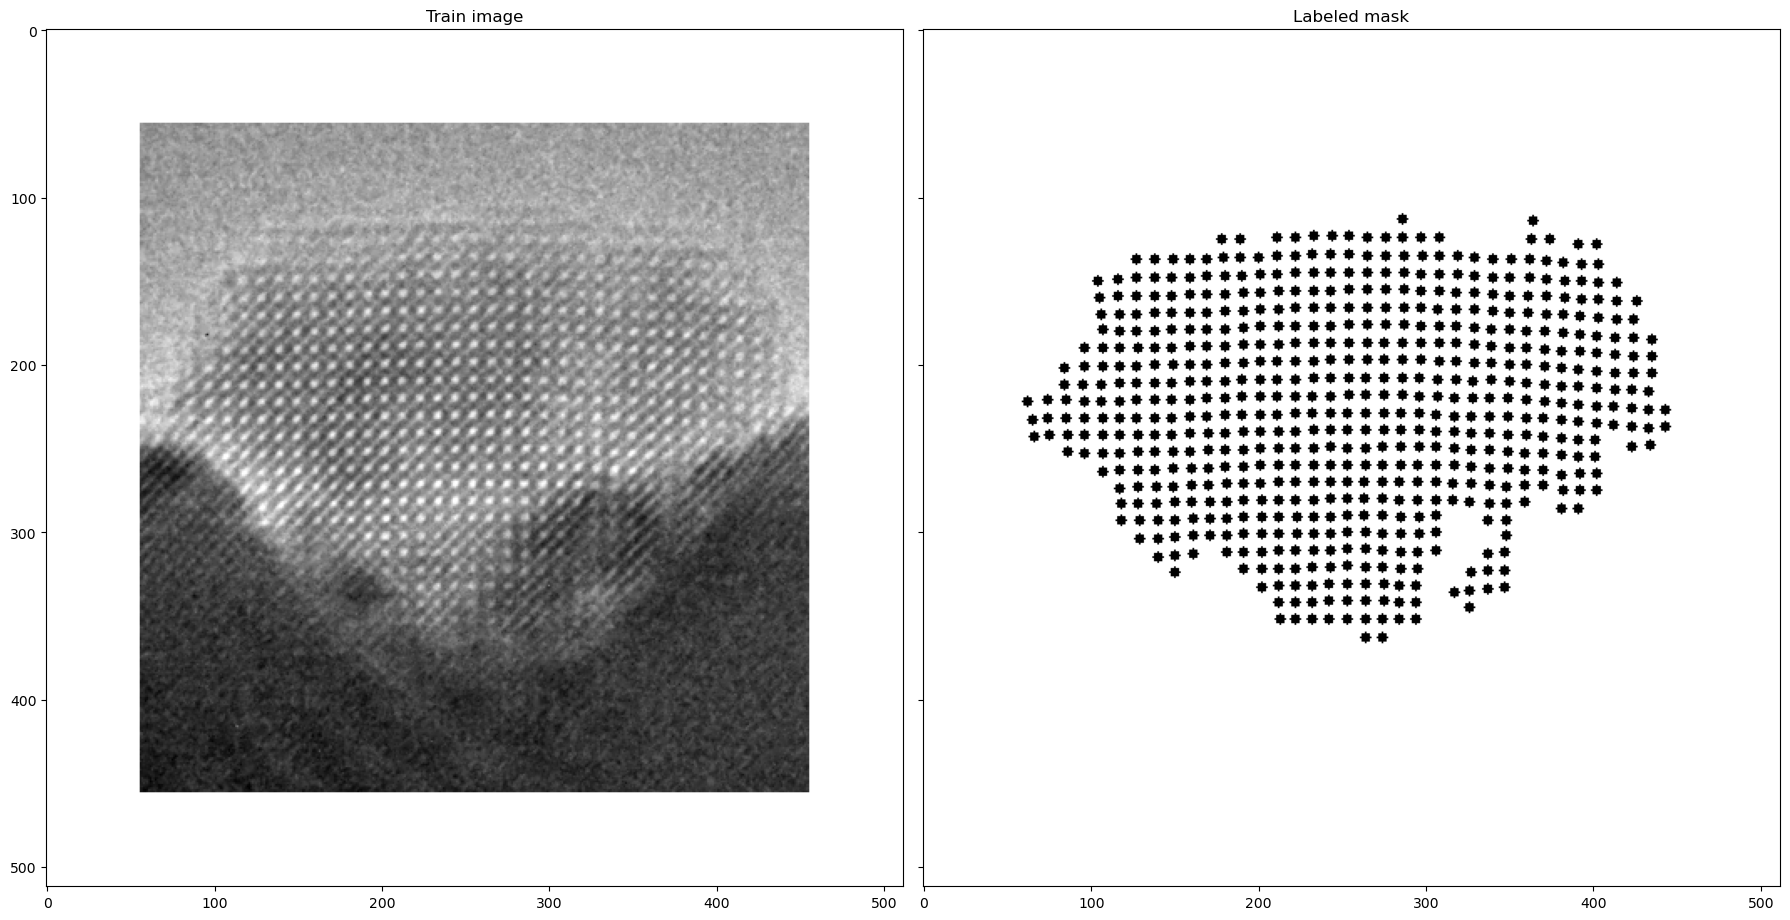

In [6]:
#test parameters on one frame
import matplotlib.pyplot as plt


j= 1

lfr=mask[j]
fr=img[j]



#The training requires 512*512 px images, so the image will be expanded with boarders
outsize=512
h1,w1=lfr.shape
h2,w2=fr.shape


# calculate the border size
border_h1 = int((outsize-h1)/2)
border_w1 = int((outsize-w1)/2)
border_h2 = int((outsize-h2)/2)
border_w2 = int((outsize-w2)/2)

# Add a white border to the image
lfr = cv2.copyMakeBorder(lfr, border_h1, border_h1, border_w1, border_w1, cv2.BORDER_CONSTANT, value=255)
fr = cv2.copyMakeBorder(fr, border_h2, border_h2, border_w2, border_w2, cv2.BORDER_CONSTANT, value=255)

#convert mask into binary
_, binary_mask = cv2.threshold(lfr, 127, 255, cv2.THRESH_BINARY)

## Some varients to the train image

# #Add gaussian blur to the train image
# kernel = 1
# fr = cv2.GaussianBlur(fr, (kernel, kernel), 0)


fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)

ax = axes.ravel()

ax[0].set_title('Train image')
ax[0].imshow(fr,cmap='gray')

ax[1].set_title('Labeled mask')
ax[1].imshow(binary_mask,cmap='gray')

plt.tight_layout()
plt.show()

In [7]:
#Apply to the entire stack

#export every other image as the training set (50%)

nFrames,h,w=mask.shape

import tqdm

for i in tqdm.tqdm(range(int(nFrames/2))):
    lfr=mask[i*2]
    fr=img[i*2]
    # Add a white border to the image
    lfr = cv2.copyMakeBorder(lfr, border_h1, border_h1, border_w1, border_w1, cv2.BORDER_CONSTANT, value=255)
    fr = cv2.copyMakeBorder(fr, border_h2, border_h2, border_w2, border_w2, cv2.BORDER_CONSTANT, value=255)
    
    #convert mask into binary
    _, binary_mask = cv2.threshold(lfr, 127, 255, cv2.THRESH_BINARY)
    
    #generate output file name
    Trainfilename = os.path.join(Train_path, f'{i:03d}.tif') 
    Labelfilename = os.path.join(Label_path, f'{i:03d}.tif') 

    cv2.imwrite(Trainfilename,fr)
    cv2.imwrite(Labelfilename,binary_mask)

#export all frames as test images
n2,h2,w2=img.shape
for k in tqdm.tqdm(range(n2)):
    fr=img[k]
    fr = cv2.copyMakeBorder(fr, border_h2, border_h2, border_w2, border_w2, cv2.BORDER_CONSTANT, value=255)
    #generate output file name
    Testfilename = os.path.join(Test_path, f'{k:03d}.tif') 

    cv2.imwrite(Testfilename,fr)


100%|██████████████████████████████████████████| 698/698 [00:01<00:00, 502.07it/s]


In [47]:
i=1
filename = os.path.join(Train_path, f'{i:03d}.tif')  # Format the filename with leading zeros

print(filename)

/Users/monali/Library/CloudStorage/OneDrive-UniversityofPittsburgh/DataProcess/Neural Network Training/Experiment data/Train/001.tif
